In [1]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import plotly.graph_objects as go

import torch

from tqdm import tqdm

# Binary Trade Classifier (LSTM) — Training Template

Trains a binary sequence classifier to identify high-probability trade entries (**BUY** or **SELL** vs. **HOLD**) using causal triple-barrier labeling.

**To use this notebook as a template:**
1. Set all experiment parameters in the **Configuration** cell below
2. Adjust label params, model architecture, and loss weights as needed
3. Run all cells sequentially — the trained model pack is saved to `Engine/Model Packs/`

| Component | Description |
|---|---|
| Labels | Causal triple-barrier with Hi/Lo trend filter |
| Features | OHLCV + ATR + regime indicators (parity with live engine) |
| Model | `LSTMAttentionSEClassifier` — BiLSTM + Squeeze-Excite + scaled-dot attention pooling |
| Loss | `BinaryTradeProfitabilityLoss` — focal CE with precision/recall weighting |

In [2]:
# ── DATASET & TASK ────────────────────────────────────────────────────────────
DS_NAME      = '../data/US500_1minute.csv'  # Path to OHLCV CSV
BINARY_TASK  = 'sell'                         # 'buy' or 'sell'
TEST_START   = '2026-01-01'                  # Date to split train / validation
N_ROWS       = None                          # Max rows to load (None = all)

# ── SEQUENCE & BATCH ──────────────────────────────────────────────────────────
SEQ_LEN      = 256    # 256 × 1-min ≈ 4 hours
BATCH_SIZE   = 512    # Mini-batch size

# ── OPTIMISER ─────────────────────────────────────────────────────────────────
NUM_EPOCHS   = 10     # Training epochs
BASE_LR      = 1e-4   # Initial learning rate (linear warmup + cosine decay)
WEIGHT_DECAY = 1e-3   # AdamW weight decay

# ── PREPROCESSING ─────────────────────────────────────────────────────────────
HOLDOUT_SIZE    = 0.10                # Fraction of training data used as internal holdout
ROLLOVER_WINDOW = ('21:30', '22:00')  # Broker rollover window — bars excluded from targets
TRADING_HOURS   = None # ('07:00', '20:00')  # Anchor-time gate: only sequences whose prediction
                                      # timestamp (last bar of window) falls in this range
                                      # are used for training/validation.
                                      # The lookback window CAN include pre-session bars.
                                      # Set to None to disable (use all hours).

# ── FEES & COMMISSIONS ────────────────────────────────────────────────────────
COMMISSION   = 0.10   # Broker commission as a fraction of trade outcome (e.g. 0.10 = 10%)
                      # Applied to all closed trades: wins are reduced, losses are increased.
                      # E.g. outcome 1.0 → 0.90, outcome -1.0 → -1.10

# ── EXPORT ────────────────────────────────────────────────────────────────────
MODEL_VERSION = 'fastma_very_selective_deep'  # Version tag appended to saved model pack filename

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## Load Dataset

In [3]:
def load_ohlcv(ds_name, n_rows=None):
    df = pd.read_csv(ds_name)
    if n_rows is not None:
        df = df.tail(n_rows)
    df = df.sort_values('Time').reset_index(drop=True)
    return df

def train_val_split(df, test_date=None):
    if test_date is None:
        return df, None
    test_start = df[df['Time'] > test_date].index[0]
    df_test = df.iloc[test_start:,:].copy().reset_index(drop=True)
    df_train = df[df['Time'] < test_date].reset_index(drop=True)
    return df_train, df_test

df = load_ohlcv(DS_NAME, N_ROWS)
df, df_test = train_val_split(df, TEST_START)
print(f"Train: {len(df):,} rows | Val: {len(df_test):,} rows")


Train: 3,153,645 rows | Val: 52,051 rows


## Label Configuration

Tune the triple-barrier parameters to control entry selectivity.  
Higher `tp_mult`/`sl_mult` ratio → fewer but better-quality entries.  
Increase `trend_pullback_thresh` to require stronger trend confirmation.

In [4]:
from Learn.labels import causal_triple_barrier_hilow_trend_labeler, calculate_trade_outcomes_all_candles

# ── Regime detection ─────────────────────────────────────────────────────────
regime_params = {
      "ma_period": 15,
      "slope_smoothness": 30,
      "regime_min_duration": 0,
      "atr_window": 60,
      "atr_lookback": 1440,
      "atr_percentile": 0.0,
      "slope_threshold": 0.02
    }

# ── Triple-barrier labelling ──────────────────────────────────────────────────
label_params = {
      "z_window": 14,
      "z_thresh": 1,
      "z_limit": 5,
      "atr_window": 14,
      "tp_mult": 2.5,
      "sl_mult": 2.5,
      "max_horizon": 90,
      "trend_pullback_thresh": 1.0,
      "regime_params": regime_params,
      "skip_range": True
    }

## Generate Trade Entry Labels

Uses `causal_triple_barrier_hilow_trend_labeler` — all parameters are fully causal (no lookahead).  
Only bars where a trade **wins** (`label == 1`) are assigned a directional target (`1` = buy, `-1` = sell); all other bars are `0` (HOLD).  
Bars during the broker rollover window (21:30–22:00) are always zeroed out.

In [5]:
# Calculate signals and create target labels for train and test sets
for name, d in [('df', df), ('df_test', df_test)]:
    signals = causal_triple_barrier_hilow_trend_labeler(d, **label_params).rename(columns={'side': 'target'})
    winning = signals[signals['label'] == 1]
    d['target'] = 0
    d.loc[winning.index, 'target'] = winning['target']

    # Zero-out targets during rollover window
    if not pd.api.types.is_datetime64_any_dtype(d['Time']):
        d['Time'] = pd.to_datetime(d['Time'])
    rollover = (d['Time'].dt.time >= pd.to_datetime(ROLLOVER_WINDOW[0]).time()) & \
               (d['Time'].dt.time <  pd.to_datetime(ROLLOVER_WINDOW[1]).time())
    d.loc[rollover, 'target'] = 0
    print(f"{name}: {rollover.sum()} rollover rows zeroed | target dist:\n{d['target'].value_counts()}\n")

df_val = df_test.copy()


df: 26934 rollover rows zeroed | target dist:
target
 0    3017311
 1      70155
-1      66179
Name: count, dtype: int64

df_test: 978 rollover rows zeroed | target dist:
target
 0    49556
 1     1319
-1     1176
Name: count, dtype: int64



## Calculate Trade Outcomes

Computes per-bar TP/SL/timeout outcomes for every candle (both directions).  
Winning outcomes (`buy_outcome` / `sell_outcome == 1`) are doubled to increase the reward signal for correct predictions.

In [6]:
# Calculate trade outcomes for ALL candles (both buy and sell)
outcome_params = {k: v for k, v in label_params.items() if k in ['atr_window', 'tp_mult', 'sl_mult', 'max_horizon']}
outcome_params['max_horizon'] = 1000

for name, d, outcomes_df in [('df', df, None), ('df_test', df_test, None)]:
    outcomes = calculate_trade_outcomes_all_candles(d, **outcome_params)
    # Double TP rewards
    for col in ['buy_outcome', 'sell_outcome']:
        outcomes[col] = outcomes[col].clip(upper=None).where(outcomes[col] <= 0, outcomes[col] * 2)
    if name == 'df':
        df_outcomes = outcomes
    else:
        df_test_outcomes = outcomes

    tp  = (outcomes['buy_outcome'] == 1).sum()
    sl  = (outcomes['buy_outcome'] == -1).sum()
    to  = (outcomes['buy_outcome'] == 0).sum()
    stp = (outcomes['sell_outcome'] == 1).sum()
    ssl = (outcomes['sell_outcome'] == -1).sum()
    sto = (outcomes['sell_outcome'] == 0).sum()
    print(f"\n{name} outcomes | Buy  TP:{tp} TO:{to} SL:{sl} | Sell TP:{stp} TO:{sto} SL:{ssl}")

print('\nTrain target dist (%):\n', df['target'].value_counts(normalize=True).mul(100).round(1))



df outcomes | Buy  TP:0 TO:0 SL:1814380 | Sell TP:0 TO:1 SL:1869962

df_test outcomes | Buy  TP:0 TO:0 SL:31154 | Sell TP:0 TO:0 SL:30558

Train target dist (%):
 target
 0    95.7
 1     2.2
-1     2.1
Name: proportion, dtype: float64


## Binary Setup: Hold vs Sell or Hold vs Buy
We'll derive two binary label columns from the outcomes and select one via `BINARY_TASK` for training.

In [7]:
# Create binary labels: 1 = winning trade, 0 = HOLD (timeout/SL)
outcome_col = 'sell_outcome' if BINARY_TASK == 'sell' else 'buy_outcome'
target_col_name = 'sell_y' if BINARY_TASK == 'sell' else 'buy_y'
positive_name = 'SELL' if BINARY_TASK == 'sell' else 'BUY'
negative_name = 'HOLD'

for d, outcomes in [(df, df_outcomes), (df_val, df_test_outcomes)]:
    d['sell_y'] = (d['target'] == -1).astype(int)
    d['buy_y']  = (d['target'] ==  1).astype(int)
    d['outcomes'] = outcomes[outcome_col].fillna(0.0)

print(f"Binary task: {BINARY_TASK.upper()} (1 = {positive_name}, 0 = {negative_name})")
print('Train:\n', df[target_col_name].value_counts(normalize=True))
print('Val:\n',   df_val[target_col_name].value_counts(normalize=True))


Binary task: SELL (1 = SELL, 0 = HOLD)
Train:
 sell_y
0    0.979015
1    0.020985
Name: proportion, dtype: float64
Val:
 sell_y
0    0.977407
1    0.022593
Name: proportion, dtype: float64


## Feature Engineering

Adds technical indicators to the OHLCV data.  
Features are computed in-parity with the live trading engine to prevent training/inference mismatch.

In [8]:
from Learn.features import add_selected_features

# Feature parity with live Engine; directional/causal features already included
df = add_selected_features(df, regime_params=regime_params)
df_val = add_selected_features(df_val, regime_params=regime_params)


## Preprocessing & Scaling

The scaler is **fit on the training split only** and then applied to the validation split to prevent data leakage.

In [9]:
from Learn.preprocess import preprocess_ohlcv

preprocess_ohlcv_args = {
    'target_col': target_col_name,
    'outcomes_col': 'outcomes',
    'shift': 0,
    'onehot_prefixes': ['OH_'],
    'price_prefixes': ['PR_'],
}

# Split BEFORE scaling to prevent data leakage
split_idx = int(len(df) * (1 - HOLDOUT_SIZE))

# Fit scaler on train only, transform both
# proc_df is the preprocessed dataframe (NaN rows dropped, index reset) — used for time alignment
X_train, y_train, scaler, features, outcomes_train, proc_df_train = preprocess_ohlcv(
    df.iloc[:split_idx].copy(), **preprocess_ohlcv_args, scaler=None, return_df=True)

X_test, y_test, _, _, outcomes_test, proc_df_test = preprocess_ohlcv(
    df.iloc[split_idx:].copy(), **preprocess_ohlcv_args, scaler=scaler, return_df=True)

X_train = np.ascontiguousarray(X_train)
X_test  = np.ascontiguousarray(X_test)

outcomes_train = np.asarray(outcomes_train, dtype=float)
outcomes_test  = np.asarray(outcomes_test, dtype=float)

y_train = [int(x) for x in y_train]
y_test  = [int(x) for x in y_test]

train_idx = list(range(len(X_train)))
test_idx  = list(range(len(X_test)))

# ── Anchor-time session gating ────────────────────────────────────────────────
# For sequence i (start index), the prediction anchor is at row i + SEQ_LEN - 1.
# We only include sequences whose anchor timestamp falls within TRADING_HOURS.
# The lookback window (prior SEQ_LEN bars) may include pre-session candles — this
# is intentional: a model predicting at 07:00 benefits from overnight context.
def _session_seq_indices(times, seq_len, trading_hours):
    """Return valid sequence-start indices filtered by anchor-time trading hours."""
    if trading_hours is None:
        return list(range(len(times) - seq_len))
    t_start = pd.to_datetime(trading_hours[0]).time()
    t_end   = pd.to_datetime(trading_hours[1]).time()
    return [
        i for i in range(len(times) - seq_len)
        if t_start <= pd.Timestamp(times[i + seq_len - 1]).time() < t_end
    ]

train_times = proc_df_train['Time'].to_numpy()
test_times  = proc_df_test['Time'].to_numpy()

train_seq_idx = _session_seq_indices(train_times, SEQ_LEN, TRADING_HOURS)
test_seq_idx  = _session_seq_indices(test_times,  SEQ_LEN, TRADING_HOURS)

n_train_all = len(X_train) - SEQ_LEN
n_test_all  = len(X_test)  - SEQ_LEN
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Session-gated seqs — Train: {len(train_seq_idx):,} / {n_train_all:,} "
      f"| Test: {len(test_seq_idx):,} / {n_test_all:,}  "
      f"(TRADING_HOURS={TRADING_HOURS})")


Train: (2837540, 89) | Test: (315365, 89)
Session-gated seqs — Train: 2,837,284 / 2,837,284 | Test: 315,109 / 315,109  (TRADING_HOURS=None)


## Data Loaders

`SEQ_LEN` and `BATCH_SIZE` are set in the Configuration cell above.

In [10]:
from Learn.Loaders import SequenceDataset
from torch.utils.data import DataLoader

train_ds = SequenceDataset(X_train, y_train, seq_len=SEQ_LEN, df_idx=train_idx,
                           custom_targets=None, trade_outcomes=outcomes_train,
                           seq_idx_filter=train_seq_idx)
val_ds   = SequenceDataset(X_test,  y_test,  seq_len=SEQ_LEN, df_idx=test_idx,
                           custom_targets=None, trade_outcomes=outcomes_test,
                           seq_idx_filter=test_seq_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=0)

print(f"DataLoaders ready — train batches: {len(train_loader):,} | val batches: {len(val_loader):,}")


DataLoaders ready — train batches: 5,542 | val batches: 616


## Model

`LSTMAttentionSEClassifier` — Bidirectional LSTM + LayerNorm + Squeeze-Excite gating + multi-head attention pooling.

Swap out the model class and `model_params` below to experiment with different architectures — all downstream cells remain unchanged.

| Param | Description |
|---|---|
| `hidden_dim` | LSTM hidden state size (output dim = `hidden_dim × 2` for bidirectional) |
| `num_layers` | Number of stacked BiLSTM layers |
| `bidirectional` | Use bidirectional LSTM (recommended: `True`) |
| `dropout` | Dropout between LSTM layers |
| `dropout_out` | Dropout before the output FC layer |
| `attn_heads` | Number of heads for MHA pooling — must divide `hidden_dim × 2` evenly |
| `attn_dropout` | Dropout inside multi-head attention |
| `use_learned_query` | Learned query token for attention pooling (recommended: `True`) |
| `bias_init` | Log-prior bias init `[log(1-p), log(p)]` — stabilises early training on imbalanced labels |

In [11]:
from Learn.Models import LSTMAttentionSEClassifier, LSTMClassifier

# Log-prior bias init: start output layer at the training class distribution.
# Prevents the model spending early epochs learning the prior — improves precision stability.
p_pos     = sum(y_train) / len(y_train)
bias_init = [math.log(1 - p_pos + 1e-8), math.log(p_pos + 1e-8)]
print(f"Positive class rate: {p_pos:.4f} → bias_init: [{bias_init[0]:.3f}, {bias_init[1]:.3f}]")

# # --- Profile A: baseline ---
# model_params = {
#     'input_dim':          X_train.shape[1],
#     'hidden_dim':         128,   # embed dim = 256
#     'num_layers':         2,
#     'num_classes':        2,
#     'bidirectional':      True,
#     'dropout':            0.25,
#     'dropout_out':        0.25,  # was 0.35
#     'attn_heads':         4,
#     'attn_dropout':       0.10,
#     'use_learned_query':  True,
#     'bias_init':          bias_init,
# }

# # --- Profile B: more capacity (common win) ---
# model_params = {
#     'input_dim':          X_train.shape[1],
#     'hidden_dim':         192,   # embed dim = 384
#     'num_layers':         2,
#     'num_classes':        2,
#     'bidirectional':      True,
#     'dropout':            0.20,
#     'dropout_out':        0.25,
#     'attn_heads':         8,     # 384 % 8 == 0
#     'attn_dropout':       0.05,  # slightly less attention noise
#     'use_learned_query':  True,
#     'bias_init':          bias_init,
# }

# --- Profile C: deeper (only if underfitting) ---
model_params = {
    'input_dim':          X_train.shape[1],
    'hidden_dim':         160,   # embed dim = 320
    'num_layers':         3,
    'num_classes':        2,
    'bidirectional':      True,
    'dropout':            0.25,
    'dropout_out':        0.25,
    'attn_heads':         8,     # 320 % 8 == 0
    'attn_dropout':       0.10,
    'use_learned_query':  True,
    'bias_init':          bias_init,
}

model = LSTMAttentionSEClassifier(**model_params).to(device)
MODEL_TYPE = f'LSTM_Binary_{positive_name}'
print(f"Model: {MODEL_TYPE} | Params: {sum(p.numel() for p in model.parameters()):,}")


Positive class rate: 0.0207 → bias_init: [-0.021, -3.878]
Model: LSTM_Binary_SELL | Params: 2,044,682


### Class Weights & Loss Function

Inverse-frequency class weights are computed automatically to handle the natural imbalance between HOLD and trade entry bars.  
Adjust the loss function weights below to tune the precision/recall trade-off.

In [12]:
# Inverse-frequency class weights to handle label imbalance
counts = np.maximum(np.bincount(y_train), 1)
weights = (len(y_train) / (len(counts) * counts)).astype(float)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print('Class weights:', class_weights.cpu().numpy())
print('Train distribution:\n', pd.Series(y_train).value_counts().sort_index())


Class weights: [ 0.5105662 24.16038  ]
Train distribution:
 0    2778817
1      58723
Name: count, dtype: int64


In [13]:
from Learn.Loss import BinaryTradeProfitabilityLoss

optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)

loss_params = {
    'alpha':           class_weights,
    'gamma':           2.0,       # Lower gamma is more stable early training
    'trade_class':     1,
    'pr_weight':       15.0,      # Push precision harder
    'rec_weight':      1.0,
    'f1_weight':       1.0,
    'profit_weight':   15.0,
    'loss_penalty':    5.0,       # Penalise SL predictions
    'direction_bonus': 0.0,
    'eps':             1e-6
}

criterion = BinaryTradeProfitabilityLoss(**loss_params)


## Training Loop

Runs for `NUM_EPOCHS` with **linear warmup + cosine decay** LR scheduling.  
Metrics (F1, precision, recall, cumulative profit) are plotted after each epoch.

### Experiment Notes
_Record hyperparameter observations and results here._

Epoch 5 | Acc: 0.9716 | Profit (after 10% commission): 1711 | Val Loss: 0.019825

              precision    recall  f1-score   support

        HOLD       0.99      0.98      0.99    307674
        SELL       0.43      0.62      0.51      7435

    accuracy                           0.97    315109
   macro avg       0.71      0.80      0.75    315109
weighted avg       0.98      0.97      0.97    315109



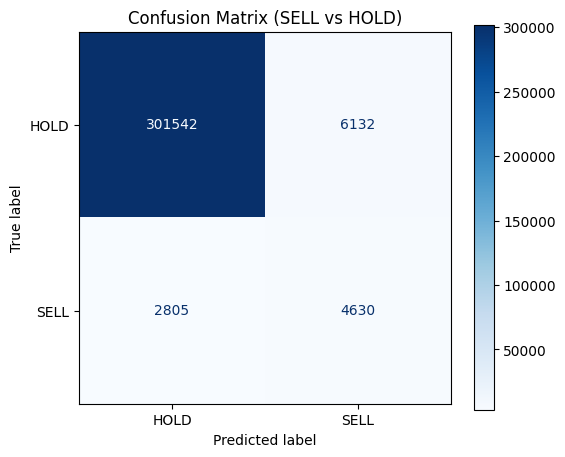

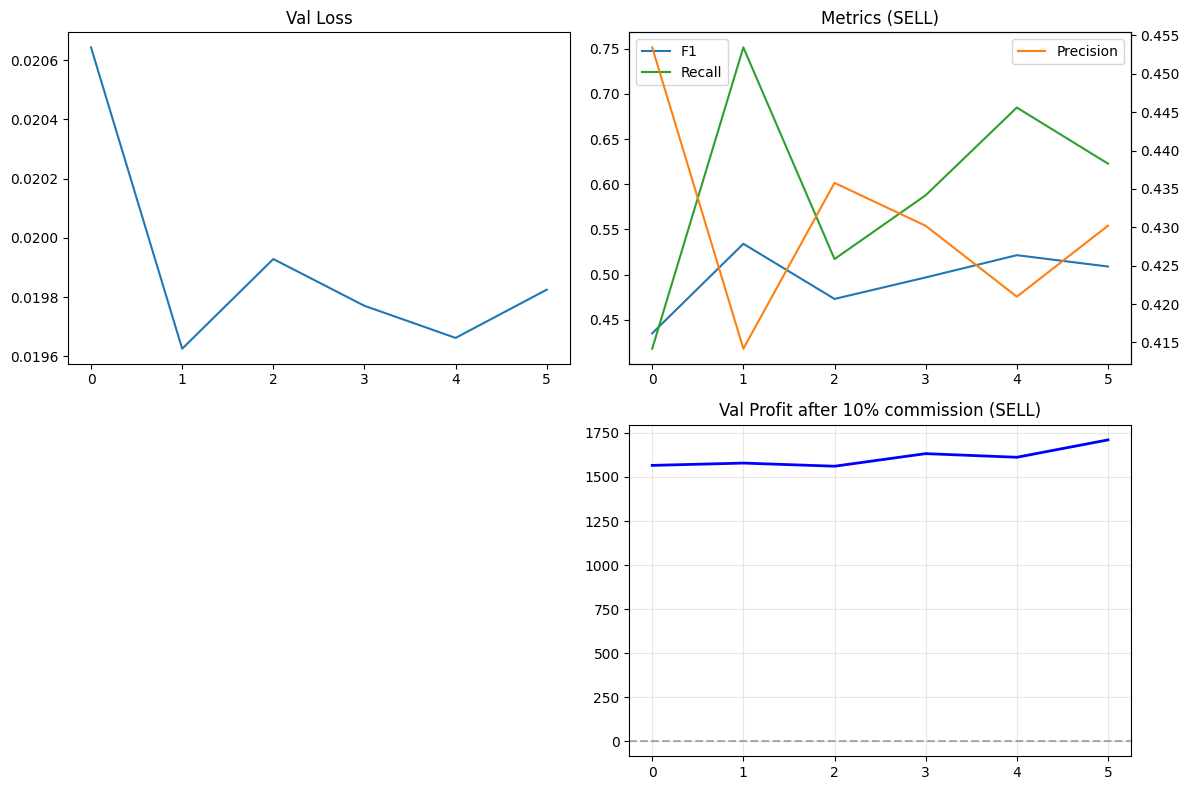

Epoch 6:   0%|          | 0/5542 [00:00<?, ?it/s]C:\Users\Stuart\AppData\Local\Temp\ipykernel_30028\1511634411.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 6:  32%|███▏      | 1786/5542 [06:41<14:05,  4.44it/s]


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score
from IPython.display import clear_output

# ── AMP & TF32 setup (RTX3060 / Ampere) ──────────────────────────────────────
use_amp = device.type == 'cuda'
torch.backends.cuda.matmul.allow_tf32 = True   # free ~10% speedup on Ampere GPUs
scaler_amp = torch.amp.GradScaler('cuda', enabled=use_amp)

warmup_steps = 200
total_steps  = len(train_loader) * NUM_EPOCHS

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

train_losses, val_losses_all = [], []
f1_pos, precision_pos, recall_pos, pnl = [], [], [], []

for epoch in range(NUM_EPOCHS):

    # --- Train ---
    model.train()
    train_loss = 0.0
    for xb, yb, outcome_b in tqdm(train_loader, desc=f"Epoch {epoch}"):
        xb, yb = xb.to(device), yb.to(device)
        outcome_b = outcome_b.to(device) if isinstance(outcome_b, torch.Tensor) else outcome_b
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            loss = criterion(model(xb), yb)
        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()
        scheduler.step()
        train_loss += loss.item()
    train_losses.append(train_loss / len(train_loader))

    # --- Validate ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    all_preds, all_targets, all_outcomes = [], [], []
    with torch.no_grad():
        for xb, yb, outcome_b in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            outcome_b = outcome_b.to(device) if isinstance(outcome_b, torch.Tensor) else outcome_b
            with torch.amp.autocast('cuda', enabled=use_amp):
                logits = model(xb)
                val_loss += criterion(logits, yb).item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(yb.cpu().numpy())
            all_outcomes.extend(outcome_b.cpu().numpy() if isinstance(outcome_b, torch.Tensor) else outcome_b)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    # --- Metrics ---
    all_preds_np    = np.array(all_preds)
    all_outcomes_np = np.array(all_outcomes)
    pos_mask        = (all_preds_np == 1)
    # Apply commission: wins are reduced, losses are increased (e.g. 1.0 → 0.90, -1.0 → -1.10)
    net_outcomes_np = all_outcomes_np - COMMISSION * np.abs(all_outcomes_np)
    profit          = float(net_outcomes_np[pos_mask].sum()) if pos_mask.any() else 0.0
    val_loss_value  = val_loss / total
    acc             = accuracy_score(all_targets, all_preds)
    f1p  = f1_score(all_targets, all_preds, pos_label=1)
    pp   = precision_score(all_targets, all_preds, pos_label=1)
    rr   = recall_score(all_targets, all_preds, pos_label=1)

    val_losses_all.append(val_loss_value)
    f1_pos.append(f1p); precision_pos.append(pp); recall_pos.append(rr)
    pnl.append(profit)

    # --- Plot ---
    clear_output(wait=True)
    print(f"Epoch {epoch} | Acc: {acc:.4f} | Profit (after {COMMISSION:.0%} commission): {profit:.0f} | Val Loss: {val_loss_value:.6f}\n")
    print(classification_report(all_targets, all_preds, target_names=[negative_name, positive_name]))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix(all_targets, all_preds),
                           display_labels=[negative_name, positive_name]).plot(cmap='Blues', values_format='d', ax=ax)
    ax.set_title(f'Confusion Matrix ({positive_name} vs {negative_name})')
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0,0].plot(val_losses_all); axes[0,0].set_title('Val Loss')

    ax2 = axes[0,1].twinx()
    axes[0,1].plot(f1_pos, label='F1', color='tab:blue')
    axes[0,1].plot(recall_pos, label='Recall', color='tab:green')
    ax2.plot(precision_pos, label='Precision', color='tab:orange')
    axes[0,1].set_title(f'Metrics ({positive_name})')
    axes[0,1].legend(loc='upper left'); ax2.legend(loc='upper right')

    axes[1,0].axis('off')
    axes[1,1].plot(pnl, color='blue', linewidth=2)
    axes[1,1].axhline(0, color='black', linestyle='--', alpha=0.3)
    axes[1,1].set_title(f'Val Profit after {COMMISSION:.0%} commission ({positive_name})'); axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()


## Save Model Pack

Saves the full model pack (weights, params, scaler, features, preprocessing functions) to `Engine/Model Packs/`.

In [15]:
# Save model output
import pickle
import inspect

today = pd.Timestamp.now().strftime('%Y%m%d')
ds_title = DS_NAME.split('/')[-1].split('.')[0]

model_name = '_'.join([ds_title, MODEL_TYPE, str(SEQ_LEN) + 'seq', today, MODEL_VERSION])

model_info = {
    'dataset_name': ds_title,
    'dataset_dir': DS_NAME,
    'date_trained': today,
    'model_type': MODEL_TYPE,
    'binary_task': BINARY_TASK,
    'positive_class': positive_name,
    'negative_class': negative_name,
    'seq_len': SEQ_LEN,
    'class_weights': weights.tolist(),
    'n_epochs': NUM_EPOCHS,
}

# Serialize loss_params — convert alpha tensor to list to avoid device-bound pickle
loss_params_serializable = {**loss_params, 'alpha': loss_params['alpha'].cpu().tolist()}

with open(f'../Engine/Model Packs/{model_name}_model.pkl', 'wb') as f:
    pickle.dump({
        # ── Model ────────────────────────────────────────────────────────────
        'model':              model.state_dict(),
        'model_class':        LSTMAttentionSEClassifier,
        'model_class_source': inspect.getsource(LSTMAttentionSEClassifier),
        'model_params':       model_params,
        'model_info':         model_info,

        # ── Features & Preprocessing ─────────────────────────────────────────
        'features':                   features,
        'feature_count':              X_train.shape[1],
        'feature_function':           add_selected_features,
        'feature_function_source':    inspect.getsource(add_selected_features),
        'preprocess_function':        preprocess_ohlcv,
        'preprocess_function_source': inspect.getsource(preprocess_ohlcv),
        'preprocess_args':            preprocess_ohlcv_args,
        'scaler':                     scaler,

        # ── Labeling & Outcomes ──────────────────────────────────────────────
        'label_function':          causal_triple_barrier_hilow_trend_labeler,
        'label_function_source':   inspect.getsource(causal_triple_barrier_hilow_trend_labeler),
        'label_params':            label_params,
        'regime_params':           regime_params,
        'outcome_params':          outcome_params,
        'rollover_window':         ROLLOVER_WINDOW,

        # ── Training Config ──────────────────────────────────────────────────
        'input_shape':  (SEQ_LEN, X_train.shape[1]),
        'loss_params':  loss_params_serializable,
        'loss_function': BinaryTradeProfitabilityLoss,
        'loss_function_source': inspect.getsource(BinaryTradeProfitabilityLoss),
        'data_split': {
            'test_start_date': TEST_START,
            'train_rows': len(X_train),
            'val_rows':   len(X_test),
            'holdout_size': HOLDOUT_SIZE,
        },
        'torch_version': torch.__version__,

        # ── Validation Metrics ───────────────────────────────────────────────
        'val_metrics': {
            'final_f1':        f1_pos[-1],
            'final_precision': precision_pos[-1],
            'final_recall':    recall_pos[-1],
            'final_profit':    pnl[-1],
            'best_f1':         max(f1_pos),
            'best_precision':  max(precision_pos),
            'f1_curve':        f1_pos,
            'precision_curve': precision_pos,
            'recall_curve':    recall_pos,
            'pnl_curve':       pnl,
        },
    }, f)

print('Saved', model_name)


Saved US500_1minute_LSTM_Binary_SELL_256seq_20260308_fastma_very_selective_deep
